# freeCAM PI-atm

This notebook follows the same object-oriented UI as FreeCESM. Machine paths, run-directory preparation, PBS submission, `mpiexec`, and the persistent socket are implementation details hidden by `freecam.Driver`.

In [1]:
%load_ext autoreload
%autoreload 2

import freecam as fc
import numpy as np

## 1. Create one model

Constructing the driver is cheap and does not submit a job. A `CaseConfig` can declare a custom atmosphere workflow before MPI starts. Its factory receives the complete validated default order, so it only needs to describe the changes. Here the same Python physics class is inserted twice; freeCAM creates two independent runtime process instances.

In [2]:
class VolcanicAerosol(fc.Physics):
    name = 'volcanic_aerosol'
    writes = ('phys_state.t',)

    def run(self, state, context):
        # Deliberately visible demonstration cooling: 0.18 K per call at dt=1800 s.
        state.T -= 1.0e-4 * context.timestep_seconds


def volcanic_workflow(default):
    workflow = default.copy()
    workflow.insert_after('dadadj', VolcanicAerosol())
    workflow.insert_before('radiation_tend', VolcanicAerosol())
    return workflow


volcanic_case = fc.CaseConfig(
    name='PI-atm-volcanic',
    description='PI-atm with two Python aerosol tendencies',
    forcing='1850 prescribed SST and sea ice plus volcanic aerosol',
    make_atm=lambda: fc.FreeCAM(workflow=volcanic_workflow),
)

driver = fc.Driver(
    case=volcanic_case,
    nsteps=2,
    history_every=1,
    restart_every='end',
    # This experiment intentionally changes CAM output, so replay only x2a inputs.
    verify_boundary_exports=False,
)
display(driver.preview().describe())  # does not submit PBS or start MPI
display(driver.diagnose())             # checks paths/account without launching

({'index': 0,
  'name': 'surface_fluxes_and_emissions',
  'operation': 'chem_emissions',
  'kind': 'scheme',
  'implementation': 'fortran-numerical-kernel'},
 {'index': 1,
  'name': 'tracer_tendencies',
  'operation': 'leaf_tracers_timestep_tend',
  'kind': 'scheme',
  'implementation': 'fortran-numerical-kernel'},
 {'index': 2,
  'name': 'age_of_air_tendencies',
  'operation': 'leaf_aoa_tracers_timestep_tend',
  'kind': 'scheme',
  'implementation': 'fortran-numerical-kernel'},
 {'index': 3,
  'name': 'chemistry_tendencies',
  'operation': 'leaf_chem_timestep_tend',
  'kind': 'scheme',
  'implementation': 'fortran-numerical-kernel'},
 {'index': 4,
  'name': 'vertical_diffusion',
  'operation': 'vertical_diffusion_tend',
  'kind': 'scheme',
  'implementation': 'fortran-numerical-kernel'},
 {'index': 5,
  'name': 'rayleigh_friction',
  'operation': 'rayleigh_friction_tend',
  'kind': 'scheme',
  'implementation': 'fortran-numerical-kernel'},
 {'index': 6,
  'name': 'aerosol_dry_depositi

{'ready': True,
 'case': 'PI-atm-volcanic',
 'mpi_ranks': 512,
 'launch_mode': 'auto',
 'pbs_account': 'UCUB0188',
 'checks': {'config': True,
  'environment': True,
  'atm_in': True,
  'boundary': True,
  'python': True},
 'paths': {'config': '/glade/work/ruitong/pycam-sima-pi-cam-only/configs/pi_cam_icesm131.yaml',
  'environment': '/glade/work/ruitong/CESM_cases/f.e13.F1850C5.ne16_g16.icesm131_ihesp.PI-cam-oracle.50step/.env_mach_specific.sh',
  'atm_in': '/glade/derecho/scratch/ruitong/pyCAM/PI-cam/f.e13.F1850C5.ne16_g16.icesm131_ihesp.PI-cam-oracle.50step/run/atm_in',
  'boundary': '/glade/derecho/scratch/ruitong/pyCAM/PI-cam/nonpic-boundary-capture-50step/boundary/replay/manifest.json',
  'python': '/glade/work/ruitong/pycam-sima-pi-cam-only/.venv/bin/python'}}

### Start the persistent model

This is the one expensive startup call: it submits PBS, starts 512 MPI ranks, initializes CAM, and then keeps the model alive for all following cells.

In [3]:
driver.initialize()
display({
    'persistent_job': driver.status.get('job_id', 'managed by Driver'),
    'run_directory': driver.run_dir,
})

PI-CAM Notebook worker submitted as 7107578.desched1; waiting for 512 ranks ...


{'persistent_job': 'managed by Driver',
 'run_directory': PosixPath('/glade/derecho/scratch/ruitong/freeCAM/PI-cam/notebook-20260813-001622-3430657e/run')}

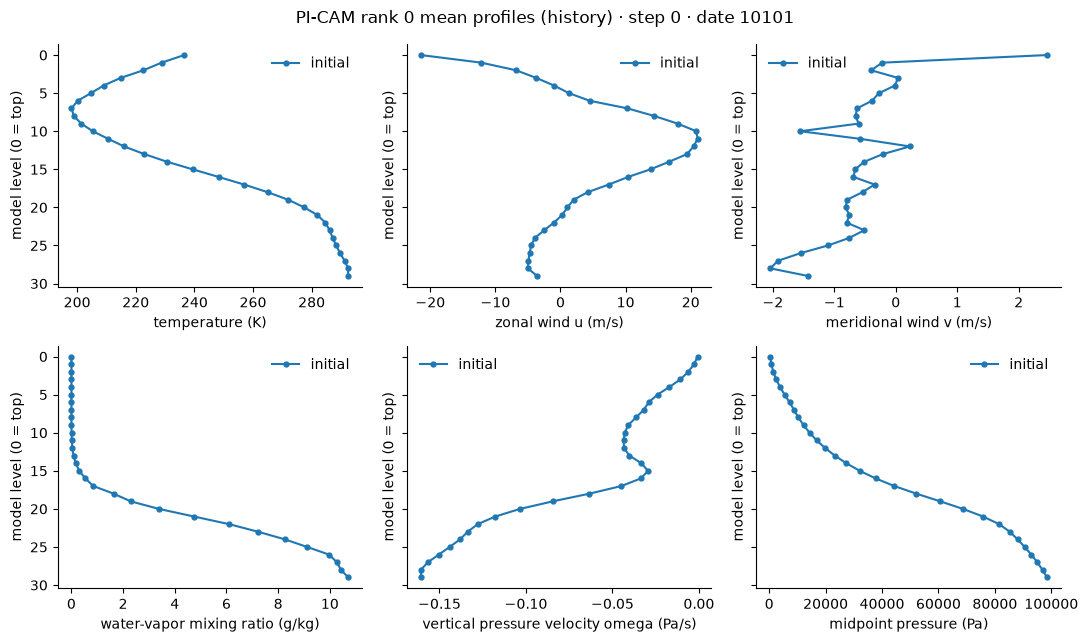

In [4]:
plot_variables = (
    'T', 'u', 'v', 'q',
    'omega', 'pmid',  # unique StatePool leaf names become safe shortcuts
)
profiles = driver.cam.state.plot(
    rank=0, variables=plot_variables, figsize=(11, 6.5),
    mode='history', label='initial',
)
fig, axes = profiles  # optional direct Matplotlib access
initial_profiles = {
    variable: np.asarray(axis.lines[-1].get_xdata()).copy()
    for axis, variable in zip(axes.flat, plot_variables)
}
display(profiles)

## 2. Inspect and run the Python-owned workflow

The default workflow view is the scientific-process order, written as one explicit Python list just like FreeCESM. Assigning the list atomically reorders those scientific slots on every MPI rank while required control, clock, boundary, and I/O actions keep their source positions. Use `workflow.debug` only when diagnosing that complete internal order.

CAM step 2/2 (model step 2, date 10101)


steps,2 / 2
model step,2
date,10101
process calls,98


{'T': {'min': -0.24906483219837128,
  'max': 0.8070728625341985,
  'mean': 0.16126187986165236,
  'maximum_absolute_change': 0.8070728625341985},
 'u': {'min': -1.359147299706244,
  'max': 0.16681963344784445,
  'mean': -0.13343735615305535,
  'maximum_absolute_change': 1.359147299706244},
 'v': {'min': -1.8584822401836698,
  'max': -0.07339864502352667,
  'mean': -0.4737801314941041,
  'maximum_absolute_change': 1.8584822401836698},
 'q': {'min': -0.05470505296407824,
  'max': 0.06607134045795071,
  'mean': 0.0035595120462983193,
  'maximum_absolute_change': 0.06607134045795071},
 'omega': {'min': -7.787524641143296e-05,
  'max': 0.051592091065793974,
  'mean': 0.02734325297131951,
  'maximum_absolute_change': 0.051592091065793974},
 'pmid': {'min': 0.0,
  'max': 75.9115918501193,
  'mean': 26.603783982464908,
  'maximum_absolute_change': 75.9115918501193}}

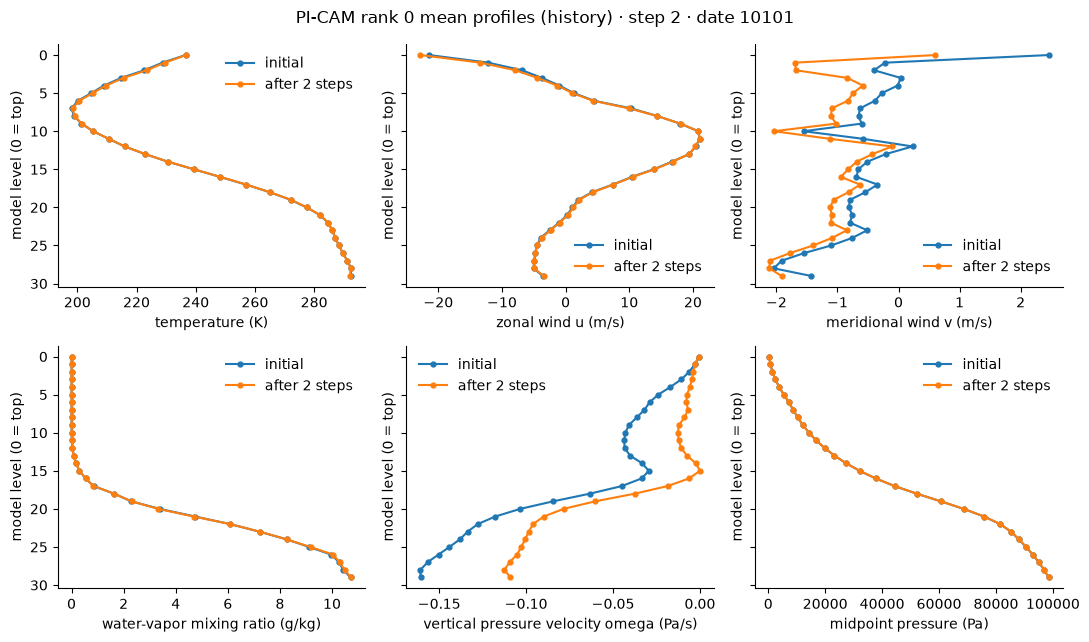

In [5]:
result = driver.run(progress=True)
display(result)  # compact summary; full detail remains in result.trace

# History mode retains the initial curves and adds the current StatePool.
profiles.capture(label='after 2 steps', color='tab:orange')
profile_changes = {}
for axis, variable in zip(axes.flat, plot_variables):
    after = np.asarray(axis.lines[-1].get_xdata())
    change = after - initial_profiles[variable]
    profile_changes[variable] = {
        'min': float(change.min()),
        'max': float(change.max()),
        'mean': float(change.mean()),
        'maximum_absolute_change': float(np.abs(change).max()),
    }
display(profile_changes)
display(profiles)

In [6]:
# The default view contains scientific processes only. CAM control, clock,
# boundary, and I/O actions remain active and are available under .debug.
workflow = driver.cam.workflow
source_order = workflow[:]

# Reordering uses ordinary Python list operations.
radiation = workflow['radiation']
vertical_diffusion = workflow['vertical_diffusion']
custom_order = source_order.copy()
custom_order.remove(radiation)
custom_order.insert(custom_order.index(vertical_diffusion), radiation)
workflow[:] = custom_order

display(workflow)
workflow[:] = source_order  # restore the validated PI-CAM order before running

#,process,implementation
0,surface_fluxes_and_emissions,fortran-numerical-kernel
1,tracers_and_chemistry,fortran-numerical-kernel
2,tracer_tendencies,fortran-numerical-kernel
3,age_of_air_tendencies,fortran-numerical-kernel
4,chemistry_tendencies,fortran-numerical-kernel
5,radiation,fortran-numerical-kernel
6,vertical_diffusion,fortran-numerical-kernel
7,aerosol_dry_deposition,fortran-numerical-kernel
8,rayleigh_friction,fortran-numerical-kernel
9,aerosol_dry_deposition,fortran-numerical-kernel


## 3. Add a variable and a Python physics process

Use an ordinary NumPy array for small rank-independent state. For a distributed field, `state.create(..., like='T')` reuses `T`'s rank-local layout. NumPy expressions are evaluated on every rank. A `Physics` object can be inserted directly; simple `state.field` reads and writes are inferred automatically.

In [7]:
NLEV = driver.cam.state.T.metadata['shape'][1]
driver.cam.state.rh = np.zeros(NLEV)  # same 1-D profile on every rank

driver.cam.state.create('tracer', like='T', units='kg kg-1')

class NotebookTracer(fc.Physics):
    name = 'notebook_tracer_source'
    after = 'dadadj'
    def run(self, state, context):
        state.tracer += 1.0e-6 * context.timestep_seconds

# insert() changes the list and returns None, just like list.insert().
driver.cam.workflow.insert(NotebookTracer())
tracer_process = driver.cam.workflow['notebook_tracer_source']
driver.cam.state.T[:, 0, :] += 0.0  # collective no-op slice edit
driver.cam.state.rh = np.clip(driver.cam.state.rh + 0.05, 0.0, 1.0)
driver.cam.state.tracer = np.sin(driver.cam.state.tracer)
driver.cam.workflow

#,process,implementation
0,surface_fluxes_and_emissions,fortran-numerical-kernel
1,tracers_and_chemistry,fortran-numerical-kernel
2,tracer_tendencies,fortran-numerical-kernel
3,age_of_air_tendencies,fortran-numerical-kernel
4,chemistry_tendencies,fortran-numerical-kernel
5,vertical_diffusion,fortran-numerical-kernel
6,rayleigh_friction,fortran-numerical-kernel
7,aerosol_dry_deposition,fortran-numerical-kernel
8,aerosol_dry_deposition,fortran-numerical-kernel
9,carma_aerosol_tendencies,fortran-numerical-kernel


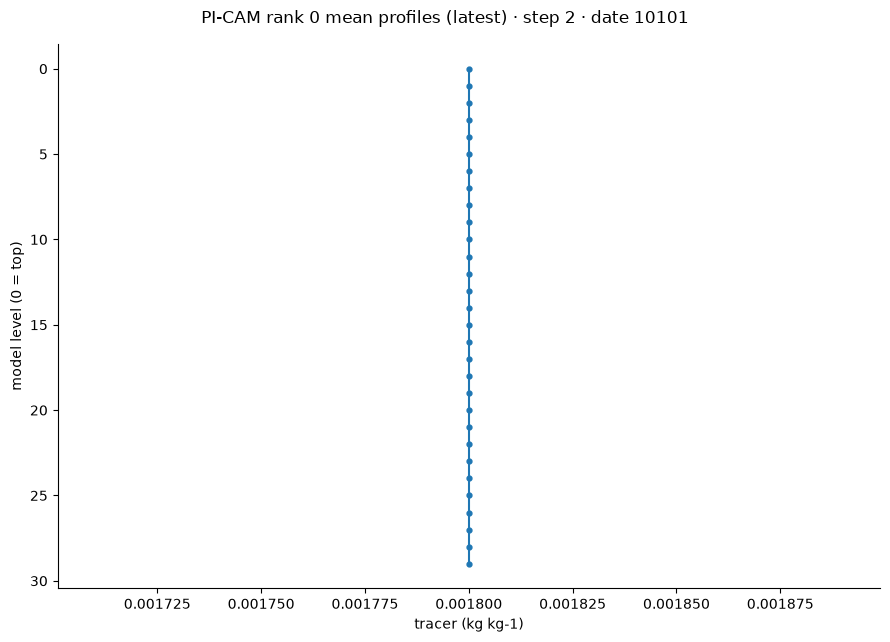

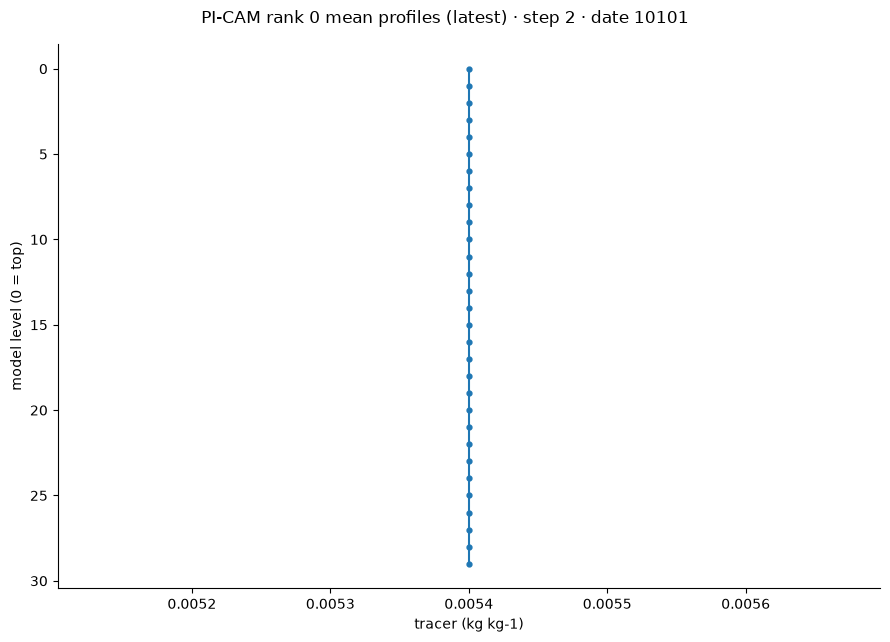

{'name': 'notebook_tracer_source',
 'phase': 'cam_run1',
 'enabled': True,
 'plan': ({'index': 0,
   'phase': 'coupling',
   'name': 'boundary_import',
   'operation': 'boundary_import',
   'kind': 'boundary',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'parent_stage': None,
   'native_id': 202,
   'enabled': True},
  {'index': 1,
   'phase': 'cam_run2',
   'name': 'prepare',
   'operation': 'prepare',
   'kind': 'kernel',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'parent_stage': None,
   'native_id': 401,
   'enabled': True},
  {'index': 2,
   'phase': 'cam_run2',
   'name': 'surface_fluxes_and_emissions',
   'operation': 'chem_emissions',
   'kind': 'scheme',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'parent_stage': None,
   'native_id': 402,
   'enabled': True},
  {'index': 3,
   'phase'

In [8]:
# Latest mode reuses one object and fetches current values on every display.
latest_tracer_plot = driver.cam.state.plot(
    rank=0, variables=('tracer',), mode='latest', label='current'
)

# Run only this process; the model clock does not advance.
tracer_process.run()
display(latest_tracer_plot)

# Replace the live callback without reinstalling or moving the process.
def revised_tracer(state, context):
    state.tracer += 2.0e-6 * context.timestep_seconds

tracer_process.reload(revised_tracer)
tracer_process.run()
display(latest_tracer_plot)  # automatically refreshes the same plot object

# The same object controls its placement and on/off state.
tracer_process.move(before='deep_convection')
tracer_process.disable()
tracer_process.enable()

## 4. Load an original Fortran process at runtime

The same `state.create(...)` interface defines its inputs. Use `like=` to reuse an existing layout or `dims=` when the Fortran interface requires an explicit layout. freeCAM generates the `bind(C)` adapter, compiles the device `.so`, loads it on every rank, and inserts the process into the workflow.

In [9]:
driver.cam.state.create(
    'runtime_temperature',
    dims=('nphys_local', 'pver'),
    units='K',
    initial=240.0,
    standard_name='runtime_plugin_temperature',
)
driver.cam.state.create(
    'runtime_temperature_increment',
    dims=(),
    units='K',
    initial=1.5,
    writable=False,
    standard_name='runtime_plugin_temperature_increment',
)

fortran_process = driver.cam.physics.install_fortran(
    driver.repo / 'examples/plugins/runtime_temperature_offset/device.yaml',
    project_root=driver.repo,
    process='runtime_temperature_offset',
    after='dadadj',
    unsafe=True,
)
fortran_process.run()
driver.cam.state.runtime_temperature.stats(rank='global')

{'rank': 'global', 'count': 414780, 'min': 241.5, 'max': 241.5, 'mean': 241.5}

## 5. Every supported physics interface

`driver.cam.physics` is a flat API: original module/subroutine nesting and CAM phases are implementation metadata, not part of the user path. The 262 former catalog-only interfaces are now runtime-process templates with generated StatePool pointer adapters. The current PI-CAM executable can load 226 of them; the other 36 belong to inactive COSP, CARMA, or legacy-radiation configurations.

In [10]:
physics = driver.cam.physics
display(physics)

# Access by the original Fortran operation or by its readable workflow alias.
dadadj = physics.dadadj
dry_adjustment = physics.dry_adjustment
display(dadadj.run())

# Every source process uses the same flat namespace.
cloud_ice = physics.cloud_fraction_fice
evaporation = physics.zm_conv_evap

# Each process has its own control handle; restore the original state here.
physics.radiation.disable()
physics.radiation.enable()

Python API,Original routine,Level,Parent stage,Capability
surface_fluxes_and_emissions,chem_emissions,stage,—,enabled
tracers_and_chemistry,tracers_chemistry,stage,—,disabled
tracer_tendencies_leaf,leaf_tracers_timestep_tend,leaf,cam_run2.tracers_and_chemistry,enabled
age_of_air_tendencies_leaf,leaf_aoa_tracers_timestep_tend,leaf,cam_run2.tracers_and_chemistry,enabled
chemistry_tendencies_leaf,leaf_chem_timestep_tend,leaf,cam_run2.tracers_and_chemistry,enabled
vertical_diffusion,vertical_diffusion_tend,stage,—,enabled
rayleigh_friction,rayleigh_friction_tend,stage,—,enabled
aerosol_dry_deposition,aero_model_drydep,stage,—,disabled
aerosol_dry_deposition_leaf,leaf_aero_model_drydep,leaf,cam_run2.aerosol_dry_deposition,enabled
carma_aerosol_tendencies_leaf,leaf_carma_timestep_tend,leaf,cam_run2.aerosol_dry_deposition,enabled


{'sequence': 152,
 'coupling_step': 3,
 'model_step': 2,
 'phase': 'direct_kernel',
 'name': 'dadadj',
 'operation': 'dadadj',
 'native_id': None}

{'name': 'radiation',
 'phase': 'cam_run1',
 'enabled': True,
 'plan': ({'index': 0,
   'phase': 'coupling',
   'name': 'boundary_import',
   'operation': 'boundary_import',
   'kind': 'boundary',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'parent_stage': None,
   'native_id': 202,
   'enabled': True},
  {'index': 1,
   'phase': 'cam_run2',
   'name': 'prepare',
   'operation': 'prepare',
   'kind': 'kernel',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'parent_stage': None,
   'native_id': 401,
   'enabled': True},
  {'index': 2,
   'phase': 'cam_run2',
   'name': 'surface_fluxes_and_emissions',
   'operation': 'chem_emissions',
   'kind': 'scheme',
   'control_owner': 'python',
   'implementation': 'fortran-numerical-kernel',
   'granularity': 'stage',
   'parent_stage': None,
   'native_id': 402,
   'enabled': True},
  {'index': 3,
   'phase': 'cam_run2',

## 6. Insert an original process into the workflow

For a process loadable in this case, `workflow.insert(...)` automatically binds its original Fortran arguments to the live StatePool and returns `None`, like a Python list. Retrieve the inserted process by name when a control handle is needed.

In [11]:
# Loadable source processes bind their StatePool context automatically.
driver.cam.workflow.insert(
    driver.cam.physics.cloud_fraction_fice,
    after='dry_adjustment',
)
cloud_process = driver.cam.workflow['cloud_fraction_fice']

# Run only this original routine, then show its named StatePool outputs.
cloud_process.run()
display({
    'fice': cloud_process.fice.stats(rank='global'),
    'fsnow': cloud_process.fsnow.stats(rank='global'),
})

# It is now a normal workflow process, not a standalone call.
cloud_process.move(before='radiation')
cloud_process.disable()
cloud_process.enable()
driver.cam.workflow

{'fice': {'rank': 'global',
  'count': 414780,
  'min': 0.0,
  'max': 1.0,
  'mean': 0.5812455153330248},
 'fsnow': {'rank': 'global',
  'count': 414780,
  'min': 0.0,
  'max': 1.0,
  'mean': 0.7317910556337113}}

#,process,implementation
0,surface_fluxes_and_emissions,fortran-numerical-kernel
1,tracers_and_chemistry,fortran-numerical-kernel
2,tracer_tendencies,fortran-numerical-kernel
3,age_of_air_tendencies,fortran-numerical-kernel
4,chemistry_tendencies,fortran-numerical-kernel
5,vertical_diffusion,fortran-numerical-kernel
6,rayleigh_friction,fortran-numerical-kernel
7,aerosol_dry_deposition,fortran-numerical-kernel
8,aerosol_dry_deposition,fortran-numerical-kernel
9,carma_aerosol_tendencies,fortran-numerical-kernel


## 7. Remove runtime extensions and close the model

Processes must be removed before deleting fields they use. `driver.close()` finalizes CAM and releases the persistent PBS/MPI session.

In [12]:
cloud_process.remove()
tracer_process.remove()
fortran_process.remove()
for process in driver.cam.configured_processes:
    process.remove()

del driver.cam.state.rh
del driver.cam.state.tracer
del driver.cam.state.runtime_temperature
del driver.cam.state.runtime_temperature_increment

driver.close()

## 8. Browse finalized history output with Xarray

History and restart files stay on the filesystem and are opened lazily after CAM finalizes them. This does not copy the distributed live StatePool into the Notebook.

<xarray.Dataset> Size: 137MB
Dimensions:        (lev: 30, ilev: 31, time: 1, ncol: 13826, nbnd: 2)
Coordinates:
  * lev            (lev) float64 240B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev           (ilev) float64 248B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time           (time) object 8B 0001-01-01 00:00:00
Dimensions without coordinates: ncol, nbnd
Data variables: (12/214)
    hyam           (lev) float64 240B ...
    hybm           (lev) float64 240B ...
    P0             float64 8B ...
    hyai           (ilev) float64 248B ...
    hybi           (ilev) float64 248B ...
    date           (time) int32 4B ...
    ...             ...
    pom_a1_SRF     (time, ncol) float32 55kB ...
    so4_a1_SRF     (time, ncol) float32 55kB ...
    so4_a2_SRF     (time, ncol) float32 55kB ...
    so4_a3_SRF     (time, ncol) float32 55kB ...
    soa_a1_SRF     (time, ncol) float32 55kB ...
    soa_a2_SRF     (time, ncol) float32 55kB ...
Attributes:
    np:               4
    ne:               16
    Conventions:      CF-1.0
    source:           CAM
    case:             f.e13.F1850C5.ne16_g16.icesm131_ihesp.PI-cam-oracle.50step
    title:            
    logname:          ruitong
    host:             dec1313
    Version:          $Name$
    revision_Id:      $Id$
    initial_file:     /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/ho...
    topography_file:  /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/US...

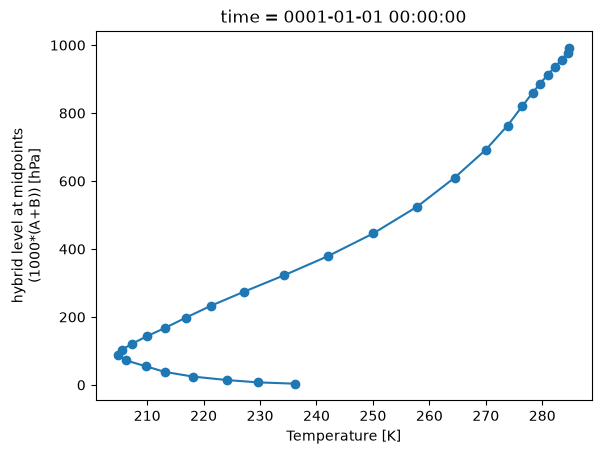

In [13]:
with driver.cam.history.open('h0') as history:
    display(history)
    temperature = history['T'].isel(time=-1)
    horizontal_dims = [name for name in temperature.dims if name != 'lev']
    temperature.mean(dim=horizontal_dims).plot(y='lev', marker='o')